# 01 · Comprender antes de comparar

**Máster Universitario en Metodología de la Investigación en Ciencias de la Salud**  
Herramientas para el Análisis Bioestadístico: Técnicas Multivariantes y Validez de las Pruebas Diagnósticas  
**Dr. Marcos Lacasa-Cazcarra · Tema 2 · Edición docente 20/09/2026**

Un cuaderno combina **celdas de texto** (explicaciones y respuestas), **celdas de código** (cálculos preparados) y **salidas** (tablas y figuras). No necesitas saber Python.

1. Abre este archivo en [Google Colab](https://colab.research.google.com/) y guarda una copia en tu Drive. Usa una sesión de CPU; no necesitas GPU ni claves.
2. Pulsa ▶ junto a la primera celda de código. Espera al mensaje de bienvenida. Ejecuta después la preparación automática.
3. Sigue el orden. Antes de ejecutar cada bloque, lee y predice. Después escribe tu interpretación mediante doble clic en «Tu respuesta».
4. Puedes ejecutar todas las celdas en orden. Las ampliaciones están al final y se pueden omitir para aprender el recorrido principal.
5. Si algo falla, reinicia la sesión y ejecuta desde el principio. Si persiste, comunica el identificador del bloque; no necesitas reparar el código. Guarda tu copia con las respuestas al acabar.

**Gemini es opcional.** Puedes pedir: «Revisa mi interpretación sin añadir cifras: [mi respuesta]. Señala qué afirmación no está apoyada por esta tabla». Contrasta siempre su respuesta con la salida y el texto. No introduzcas información identificable de pacientes.

Los apartados corresponden a **Tema 2. Análisis de supervivencia**, edición docente 20/09/2026. El enlace local funciona al conservar las carpetas de la entrega. En Colab, abre también el PDF descargado y busca el número de apartado; las prácticas no dependen de que Colab abra enlaces locales.

[PDF de teoría: Tema 2](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf)

**Duración de lectura y respuestas estimada:** 90–120 minutos, en dos sesiones. Puedes repartirla en sesiones.

In [1]:
print('Bienvenido/a. La primera celda funciona; continúa con la preparación.')

Bienvenido/a. La primera celda funciona; continúa con la preparación.


### ▶ Preparación automática
Ejecuta y espera a «Entorno preparado». La primera sesión necesita conexión para instalar la herramienta. El código se puede plegar; no lo edites.

In [2]:
NB_ID = 'SurvivalAnalysis01'
BLOQUE = 'preparacion'
PDF_REF = 'Orientacion'
import sys, subprocess, importlib.util, importlib.metadata
if importlib.util.find_spec('lifelines') is None or importlib.metadata.version('lifelines') != '0.30.3':
    print('Preparando las herramientas de supervivencia. Espera a la confirmación...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lifelines==0.30.3'])
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FixedLocator, FuncFormatter, NullFormatter
from pathlib import Path
import json, hashlib, platform, zipfile, io, base64, gzip
from IPython.display import display, Markdown, FileLink
from lifelines import KaplanMeierFitter, NelsonAalenFitter, CoxPHFitter, CoxTimeVaryingFitter, AalenJohansenFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test, proportional_hazard_test
from lifelines.utils import restricted_mean_survival_time, median_survival_times
import lifelines
from scipy import stats

OUT = Path.cwd() / 'RecursosSupervivencia' / NB_ID
OUT.mkdir(parents=True, exist_ok=True)
RECURSOS = {}
CASOS = {}
CONTEXTO = {}
AZUL, NARANJA, VERDE, MORADO = '#2166AC', '#C65D21', '#16817A', '#8055A5'
COLORES = [AZUL, NARANJA, VERDE, MORADO]
ESTILOS = ['-', '--', '-.', ':']
METODOS = {'01-00': 'Primera sesión: abrir, guardar, ejecutar, responder; Gemini opcional', '01-01': 'Qué estudia la supervivencia: contrato e historias individuales', '01-02': 'Leer S(t)', '01-03': 'Kaplan–Meier: escalones, censuras y pacientes en riesgo', '01-04': 'Supervivencia a un horizonte', '01-05': 'Mediana alcanzada y no alcanzada', '01-06': 'Incertidumbre e IC95 %', '01-07': 'Probabilidad acumulada y complemento', '01-08': 'Hazard: intensidad entre quienes siguen en riesgo', '01-09': 'HR: referencia, dirección, unidad e intervalo', '01-10': 'Mismo HR, distinto riesgo basal y diferencia absoluta', '01-11': '¿Qué pregunta quiero responder? Mapa de decisión, sin desarrollar log-rank ni p-valor', '02-01': 'Contrato del caso real, inclusiones y exclusiones', '02-02': 'Características basales; eventos y seguimiento por separado', '02-03': 'Kaplan–Meier por tratamiento', '02-04': 'S(5), IC y diferencia absoluta', '02-05': 'Log-rank global y comparaciones secundarias con Holm', '02-06': 'Confusión: hospitales con diferente edad', '02-07': 'Cox crudo y ajustado en el mismo ejemplo sintético', '02-08': 'Cox en colon: covariables, referencias y casos completos', '02-09': 'Forest plot: comparación, HR, IC e interpretación', '02-10': 'Proporcionalidad: comparación constante o cambiante', '02-11': 'Schoenfeld: patrón gráfico y contraste', '02-12': 'Forma funcional: recta y spline sin derivación', '02-13': 'Predicción de Cox: perfil, modelo, supuestos y límites para usarla en pacientes', '02-14': 'Informe clínico del caso de colon', '03-01': 'Efecto temporal: comparar horizonte y RMST', '03-02': 'Cambiar el evento: muerte, progresión y PFS', '03-03': 'Recaída con muerte competidora: incidencia acumulada', '03-04': 'Censura: distinguir cantidad y mecanismo', '03-05': 'Entrada tardía: desde cuándo se pertenece al riesgo', '03-06': 'Trasplante, intervalos y tiempo inmortal', '03-07': 'Transferencia a un segundo conjunto Open Data', '03-08': '¿Qué análisis necesito? Hoja del PDF y autoevaluación 03-08 sin cálculo nuevo', '01-A1': 'Apéndice matemático: KM, Greenwood, Cox, log-rank, transformaciones', '01-A2': 'Ampliación clínica: supervivencia condicional', '03-A1': 'Ampliación: censura izquierda y por intervalo', '03-A2': 'Ampliación: corte de calendario, análisis intermedio y multiplicidad', '03-A3': 'Ampliación: error tipo I/II y potencia en simulaciones', '02-A1': 'Ampliación de pronóstico: discriminación, calibración y validación externa'}
mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11, 'axes.titlesize': 15,
    'axes.labelsize': 11, 'axes.titleweight': 'bold', 'axes.titlepad': 15,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#8091A5', 'axes.labelcolor': '#20344B',
    'text.color': '#20344B', 'xtick.color': '#40546A', 'ytick.color': '#40546A',
    'axes.grid': True, 'grid.alpha': .18, 'grid.color': '#8091A5',
    'lines.linewidth': 2.2, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'figure.dpi': 110, 'savefig.dpi': 300, 'pdf.fonttype': 42, 'ps.fonttype': 42,
    'svg.fonttype': 'none', 'legend.frameon': False,
})

def ptexto(p):
    return 'p < 0,001' if p < .001 else f'p = {p:.3f}'.replace('.', ',')

def contexto(caso, evento, unidad, origen, **extra):
    global CONTEXTO
    CONTEXTO = dict(caso=caso, evento=evento, unidad=unidad, origen=origen, **extra)
    CASOS[caso] = CONTEXTO.copy()

def registrar(ident, archivos, descripcion):
    RECURSOS[ident] = dict(id=ident, bloque=BLOQUE, pdf=PDF_REF, metodo=METODOS.get(BLOQUE),
        convencion_IC='95 % cuando se presenta incertidumbre; intervalos puntuales. Véase pie para resultados sin IC.',
        descripcion=descripcion, contexto=CONTEXTO.copy(),
        archivos=[dict(nombre=p.name, sha256=hashlib.sha256(p.read_bytes()).hexdigest()) for p in archivos])

def figura(fig, ident, descripcion):
    diseno(fig, ident)
    archivos=[]
    for ext in ('pdf', 'svg', 'png'):
        p=OUT/f'{ident}.{ext}'; fig.savefig(p, bbox_inches='tight', facecolor='white'); archivos.append(p)
    registrar(ident, archivos, descripcion)
    plt.show()
    plt.close(fig)
    display(Markdown(f'*Figura {ident}. {descripcion}*'))

def tabla(df, ident, descripcion):
    archivos=[]
    # Conservar números en CSV; evitar que el redondeo presente p = 0,000.
    pcols=[c for c in df.columns if str(c)=='p' or str(c).startswith('p ')]
    presentacion=df.copy()
    fp=lambda x: 'No disponible' if pd.isna(x) else ('< 0,001' if x < .001 else f'{x:.3f}'.replace('.',','))
    for c in pcols: presentacion[c]=df[c].map(fp)
    for ext in ('csv', 'tex', 'html'):
        p=OUT/f'{ident}.{ext}'
        if ext=='csv': df.to_csv(p,index=False,encoding='utf-8',float_format='%.10g')
        elif ext=='tex': p.write_text(presentacion.to_latex(index=False,escape=True,float_format='%.3f'),encoding='utf-8')
        else: p.write_text(presentacion.to_html(index=False,float_format=lambda x:f'{x:.3f}'),encoding='utf-8')
        archivos.append(p)
    registrar(ident, archivos, descripcion)
    display(presentacion.style.format(precision=3,na_rep='No disponible').hide(axis='index'))
    display(Markdown(f'*Tabla {ident}. {descripcion}*'))

def datos(df, ident):
    p=OUT/f'{ident}.csv';df.to_csv(p,index=False,encoding='utf-8',float_format='%.15g')
    registrar(ident,[p],'Datos analíticos de este bloque; véase diccionario en el cuaderno.')
    RECURSOS[ident]['filas']=len(df)
    RECURSOS[ident]['columnas']=list(df.columns)

def curva(ax, km, color=AZUL, estilo='-', ci=True):
    km.plot_survival_function(ax=ax,ci_show=ci,ci_alpha=.13,show_censors=True,
        censor_styles={'marker':'+','ms':5,'mew':1},color=color,ls=estilo)
    ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.set_ylim(-.02,1.03)
    ax.set_ylabel('Probabilidad de seguir sin el evento')

def km_grupos(df, titulo, unidad, orden=None, horizonte=None, ticks=None):
    orden = orden or list(df.grupo.unique())
    max_t = horizonte if horizonte is not None else float(df.tiempo.max())
    ticks = np.linspace(0,max_t,6) if ticks is None else np.array(ticks)
    fig,(ax,ar)=plt.subplots(2,1,figsize=(9,7.5),gridspec_kw={'height_ratios':[4,1.2]})
    ajustes={}
    for j,g in enumerate(orden):
        d=df.loc[df.grupo==g];k=KaplanMeierFitter(label=g).fit(d.tiempo,d.evento);ajustes[g]=k
        curva(ax,k,COLORES[j%4],ESTILOS[j%4]);
        # Recuento justo antes de cada tiempo, sin entrada tardía en esta función.
        for t in ticks: ar.text(t,-j,str(int((d.tiempo>=t).sum())),ha='center',va='center',fontsize=10,color=COLORES[j%4])
    ax.set(title=titulo,xlabel=f'Tiempo ({unidad})',xlim=(0,max_t),xticks=ticks);ax.legend(loc='best',fontsize=10)
    ar.set(xlim=(0,max_t),ylim=(-len(orden)+.3,.75),yticks=-np.arange(len(orden)),yticklabels=orden,xticks=[])
    ar.set_title('Pacientes en riesgo justo antes del tiempo indicado',loc='left',fontsize=10,pad=9)
    for t in ticks: ar.text(t,.42,f'{t:g}',ha='center',fontsize=9,color='#607080')
    ar.grid(False); ar.tick_params(axis='y',length=0,pad=22,labelsize=10)
    for sp in ar.spines.values():sp.set_visible(False)
    fig.tight_layout(pad=2)
    return fig,ajustes

def resumen_km(ajustes, horizonte):
    filas=[]
    for g,k in ajustes.items():
        assert horizonte <= float(np.max(k.durations)), 'Horizonte fuera del seguimiento observado'
        ci=k.confidence_interval_.loc[k.confidence_interval_.index<=horizonte].iloc[-1]
        med=k.median_survival_time_
        filas.append({'Grupo':g,'N':len(k.durations),'Eventos':int(k.event_observed.sum()),
            'Censuras':int(len(k.durations)-k.event_observed.sum()),'Horizonte':horizonte,
            'S(t)':float(k.predict(horizonte)),'IC95 inferior':float(ci.iloc[0]),'IC95 superior':float(ci.iloc[1]),
            'Mediana':f'{med:.2f}' if np.isfinite(med) else 'No alcanzada'})
    return pd.DataFrame(filas)

def forest(modelo, nombres, titulo):
    s=modelo.summary.copy()
    out=pd.DataFrame({'Variable':[nombres.get(x,x) for x in s.index],
        'HR':s['exp(coef)'].values,'IC95 inferior':s['exp(coef) lower 95%'].values,
        'IC95 superior':s['exp(coef) upper 95%'].values,'p':s.p.values})
    fig,ax=plt.subplots(figsize=(9,max(3.5,.58*len(out)+1.8)))
    y=np.arange(len(out));hr=out.HR.to_numpy();lo=out['IC95 inferior'].to_numpy();hi=out['IC95 superior'].to_numpy()
    ax.errorbar(hr,y,xerr=[hr-lo,hi-hr],fmt='o',color=AZUL,ecolor=AZUL,capsize=4,ms=7)
    ax.axvline(1,color='#536678',ls='--',lw=1.4);ax.set_xscale('log')
    xmin,xmax=ax.get_xlim()
    ticks=[x for x in [.125,.25,.5,1,2,4,8,16,32,64] if xmin<=x<=xmax]
    ax.xaxis.set_major_locator(FixedLocator(ticks))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x,pos:f'{x:g}'.replace('.',',')))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set(yticks=y,yticklabels=out.Variable,xlabel='Razón de tasas instantáneas (HR), escala logarítmica',title=titulo)
    ax.invert_yaxis();ax.grid(axis='y',visible=False);fig.tight_layout(pad=2)
    return fig,out

def cerrar():
    meta=dict(cuaderno=NB_ID,version='2026-09-20-reestructuracion',python=platform.python_version(),
        paquetes={k:v for k,v in [('lifelines',lifelines.__version__),('numpy',np.__version__),('pandas',pd.__version__),('matplotlib',mpl.__version__)]},
        casos=CASOS,recursos=list(RECURSOS.values()),estado='Generado por ejecución; revisar informe docente para validación de entrega')
    (OUT/'manifest.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
    archivo=OUT.parent/f'{NB_ID}_recursos.zip'
    # Solo archivos registrados: no incluir restos de otras ejecuciones.
    nombres={'manifest.json'}|{f['nombre'] for r in RECURSOS.values() for f in r['archivos']}
    with zipfile.ZipFile(archivo,'w',zipfile.ZIP_DEFLATED) as z:
        for n in sorted(nombres):z.write(OUT/n,arcname=f'{NB_ID}/{n}')
    print(f'Práctica completada: {len(RECURSOS)} recursos preparados. Guarda tu copia con las respuestas.')
    display(FileLink(str(archivo)))
    try:
        from google.colab import files
        import ipywidgets as widgets
        boton=widgets.Button(description='Descargar figuras y tablas',layout=widgets.Layout(width='240px'))
        boton.on_click(lambda _:files.download(str(archivo)))
        display(boton)
    except ImportError:
        print('Los recursos están en la carpeta RecursosSupervivencia de esta sesión.')

print('Entorno preparado. Continúa con el siguiente bloque; no necesitas editar el código.')

Entorno preparado. Continúa con el siguiente bloque; no necesitas editar el código.


In [3]:
def diseno(fig,ident):
    """Tamaño de texto para insertar la figura a160mm en teoría."""
    import textwrap
    from matplotlib.text import Text
    minimo=8.4*fig.get_figwidth()/(160/25.4)
    for item in fig.findobj(match=Text):
        if item.get_visible() and item.get_text():item.set_fontsize(max(item.get_fontsize(),minimo))
    for ax in fig.axes:
        ancho=ax.get_position().width*fig.get_figwidth()
        ancho_texto=30 if ancho<4 else 52
        for loc in ['left','center','right']:
            title=ax.get_title(loc=loc)
            if title:ax.set_title('\n'.join(textwrap.fill(line,width=ancho_texto,break_long_words=False) for line in title.split('\n')),loc=loc,fontsize=max(minimo,14))
    if ident=='02_eventos_censuras':
        fig.axes[0].legend(loc='lower left',bbox_to_anchor=(0,1.03),ncol=2)
        fig.axes[0].set_title('Eventos y censuras durante seguimiento',pad=50)
    if ident=='01_big_agregados':
        fig.axes[0].set_title('A los 5 años\nDiferencia: 2.6 puntos')
        fig.axes[1].set_title('Durante el seguimiento\nHR: 0.81 (IC 95%)')
    if ident=='01_leer_probabilidad':
        for t in fig.axes[1].texts:t.set_position((.5,1.03));t.set_va('bottom')
        fig.axes[1].set_title('Dos probabilidades\ncomplementarias',pad=58)
        fig.axes[1].legend(loc='upper center',bbox_to_anchor=(.5,-.36),ncol=2,fontsize=minimo)
    if ident=='02_schoenfeld':
        for ax in fig.axes:
            ax.legend().remove()
        fig.axes[0].text(.03,.98,'Línea: media por tramo',transform=fig.axes[0].transAxes,va='top',fontsize=minimo)
    fig.tight_layout(pad=1.5)

In [4]:
BLOQUE='preparacion'
PDF_REF='Inicio'

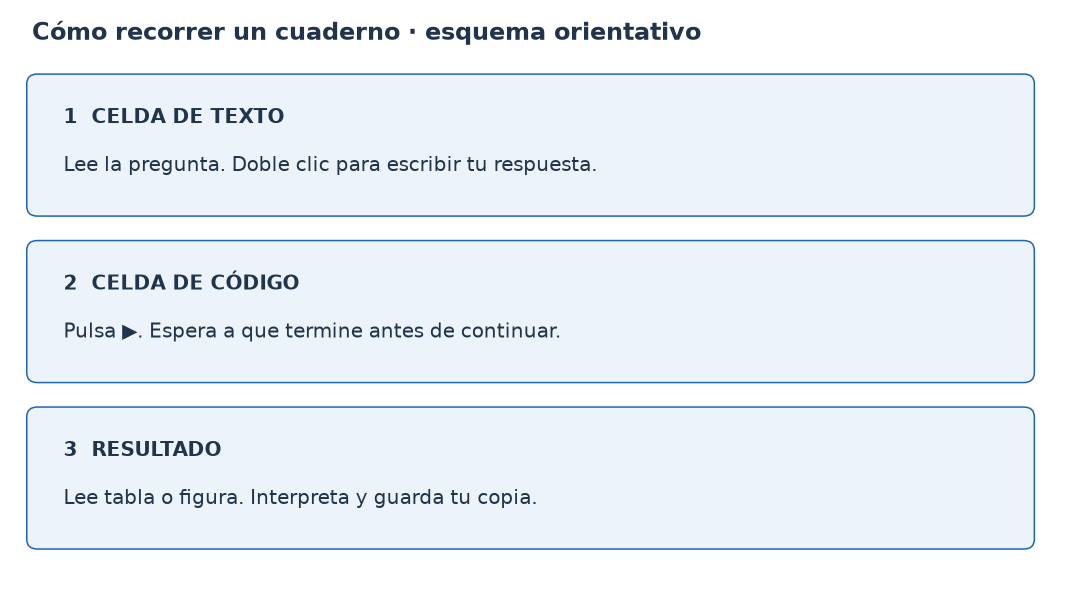

*Figura 01_colab_esquema. Esquema de acciones, no reproducción de la interfaz. Guardar el notebook conserva respuestas; descargar recursos conserva figuras y tablas.*

In [5]:
BLOQUE='01-00'
PDF_REF='Inicio'
contexto('Primer contacto con Colab','No aplica','No aplica','Esquema docente, no captura de pantalla ni interfaz ejecutada')
from matplotlib.patches import FancyBboxPatch
fig,ax=plt.subplots(figsize=(10,5.8));ax.set(xlim=(0,10),ylim=(0,6));ax.axis('off')
ax.text(.2,5.7,'Cómo recorrer un cuaderno · esquema orientativo',weight='bold',fontsize=16)
for y,title,body in [(4.0,'1  CELDA DE TEXTO','Lee la pregunta. Doble clic para escribir tu respuesta.'),
                     (2.3,'2  CELDA DE CÓDIGO','Pulsa ▶. Espera a que termine antes de continuar.'),
                     (.6,'3  RESULTADO','Lee tabla o figura. Interpreta y guarda tu copia.')]:
    ax.add_patch(FancyBboxPatch((.25,y),9.4,1.25,boxstyle='round,pad=.1',fc='#edf3fa',ec=AZUL))
    ax.text(.5,y+.85,title,fontsize=13,weight='bold')
    ax.text(.5,y+.36,body,fontsize=12)
figura(fig,'01_colab_esquema','Esquema de acciones, no reproducción de la interfaz. Guardar el notebook conserva respuestas; descargar recursos conserva figuras y tablas.')

<a id="01-01"></a>
## 01-01 · Qué estudia la supervivencia: contrato e historias individuales

**Puente al PDF:** [apartado 2.1](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-1). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Qué sabemos de cada paciente cuando termina la observación?

**Antes de ejecutar.** Distingue una muerte de una pérdida de contacto y del cierre administrativo.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

**Contrato del ejemplo:** diez pacientes ficticios con leucemia; origen en diagnóstico; evento muerte por cualquier causa; tiempo en meses; horizonte de interés 12 meses. La censura señala que conocemos la historia hasta un momento, sin observar el evento después. Quien sigue observado y sin evento integra el conjunto en riesgo. Su uso requiere que la censura no seleccione sistemáticamente un pronóstico diferente, según el análisis. Esta muestra pequeña sirve para aprender, no para evaluar eficacia.

Paciente,tiempo,evento,Fin
1,3,1,Muerte
2,7,1,Muerte
3,11,1,Muerte
4,15,1,Muerte
5,22,1,Muerte
6,5,0,Pérdida de contacto
7,8,0,Fin administrativo
8,12,0,Pérdida de contacto
9,18,0,Fin administrativo
10,24,0,Fin administrativo


*Tabla 01_diccionario_pacientes. Una fila por paciente; evento 1 = muerte, 0 = censura; tiempo en meses.*

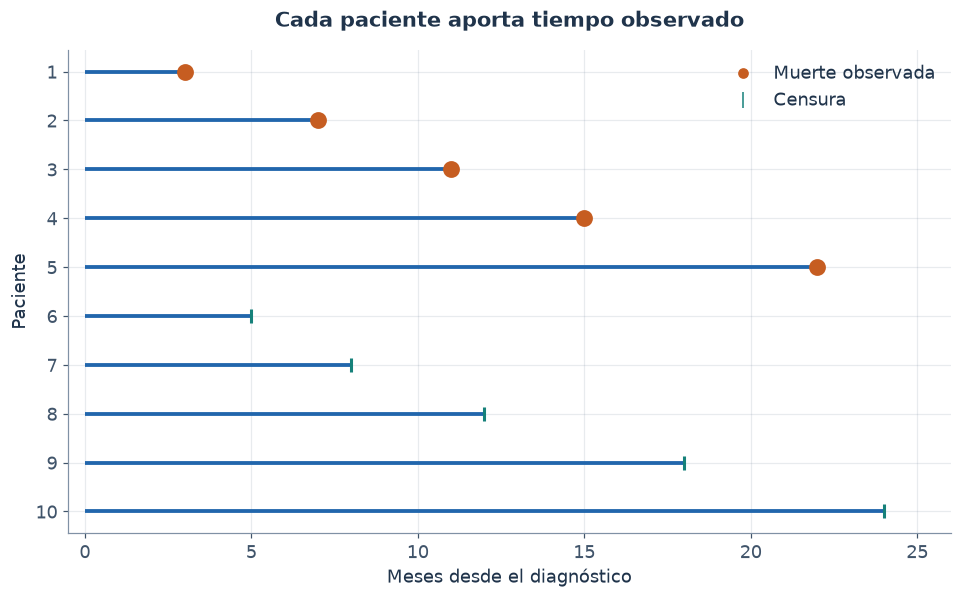

*Figura 01_lineas_seguimiento. Los trazos terminan al evento o a la última observación; los tiempos posteriores a una censura son desconocidos.*

In [6]:
BLOQUE='01-01'
PDF_REF='2.1'
contexto('Diez pacientes con leucemia','Muerte por cualquier causa','meses','Simulación didáctica fija; ejemplo del PDF',N=10)
pacientes=pd.DataFrame({'Paciente':range(1,11),'tiempo':[3,7,11,15,22,5,8,12,18,24],
    'evento':[1,1,1,1,1,0,0,0,0,0],
    'Fin':['Muerte']*5+['Pérdida de contacto','Fin administrativo','Pérdida de contacto','Fin administrativo','Fin administrativo']})
tabla(pacientes,'01_diccionario_pacientes','Una fila por paciente; evento 1 = muerte, 0 = censura; tiempo en meses.')
datos(pacientes,'01_datos_leucemia')
fig,ax=plt.subplots(figsize=(9,5.7))
for r in pacientes.itertuples():
    ax.hlines(r.Paciente,0,r.tiempo,color=AZUL,lw=2.5)
    ax.plot(r.tiempo,r.Paciente,'o' if r.evento else '|',color=NARANJA if r.evento else VERDE,ms=9,mew=2)
ax.plot([],[],'o',color=NARANJA,label='Muerte observada');ax.plot([],[],'|',color=VERDE,ms=10,label='Censura')
ax.set(yticks=range(1,11),ylabel='Paciente',xlabel='Meses desde el diagnóstico',title='Cada paciente aporta tiempo observado',xlim=(-.5,26))
ax.invert_yaxis();ax.legend(loc='upper right');fig.tight_layout()
figura(fig,'01_lineas_seguimiento','Los trazos terminan al evento o a la última observación; los tiempos posteriores a una censura son desconocidos.')

### 👀 Dónde mirar e interpretar
Una línea es una persona; círculo = muerte, barra = censura. Se conserva el tiempo conocido.

### 📝 Tu respuesta
¿Qué sabes del paciente 6 al mes 5?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Sabemos que no había muerto antes de su última observación; no sabemos qué ocurre después.

</details>

<a id="01-02"></a>
## 01-02 · Leer S(t)

**Puente al PDF:** [apartado 2.2.1](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-2-1). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Qué significa seguir vivo a los 12 meses?

**Antes de ejecutar.** Piensa en una probabilidad a un tiempo, no en el cociente bruto de supervivientes al cierre.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

**S(t)** es la probabilidad de seguir sin el evento más allá del tiempo t. Con muerte como evento, S(12) resume supervivencia a 12 meses. La estimación usa seguimientos de diferente duración.

In [7]:
BLOQUE='01-02'
PDF_REF='2.2.1'
km=KaplanMeierFitter(label='Diez pacientes ficticios').fit(pacientes.tiempo,pacientes.evento)
tabla(pd.DataFrame({'Horizonte (meses)':[12],'Supervivencia estimada':[km.predict(12)]}),'01_s12','Probabilidad estimada, no recuento bruto.')

Horizonte (meses),Supervivencia estimada
12,0.656


*Tabla 01_s12. Probabilidad estimada, no recuento bruto.*

### 👀 Dónde mirar e interpretar
La salida expresa una probabilidad entre 0 y 1; multiplícala por 100 para leer un porcentaje.

### 📝 Tu respuesta
Escribe S(12) en palabras.

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Se estima que alrededor del 65.6% seguiría vivo a 12 meses, bajo los supuestos del análisis.

</details>

<a id="01-03"></a>
## 01-03 · Kaplan–Meier: escalones, censuras y pacientes en riesgo

**Puente al PDF:** [apartado 2.2.2](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-2-2). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Por qué una censura no hace bajar la curva?

**Antes de ejecutar.** Localiza el mes 5 y después el siguiente evento.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

**Kaplan–Meier:** la estimación se actualiza en los momentos en que ocurre un evento teniendo en cuenta quién seguía en riesgo. Un evento produce un escalón; una censura reduce la información disponible después. Las cruces no son muertes. La banda se interpreta en 01-06.

Mes,En riesgo antes,Muertes,Censuras,S(t)
3.000,10,1,0,0.900
5.000,9,0,1,0.900
7.000,8,1,0,0.788
8.000,7,0,1,0.788
11.000,6,1,0,0.656
12.000,5,0,1,0.656
15.000,4,1,0,0.492
18.000,3,0,1,0.492
22.000,2,1,0,0.246
24.000,1,0,1,0.246


*Tabla 01_tabla_km. No se redondea durante el cálculo; se muestran tres decimales, CSV conserva precisión.*

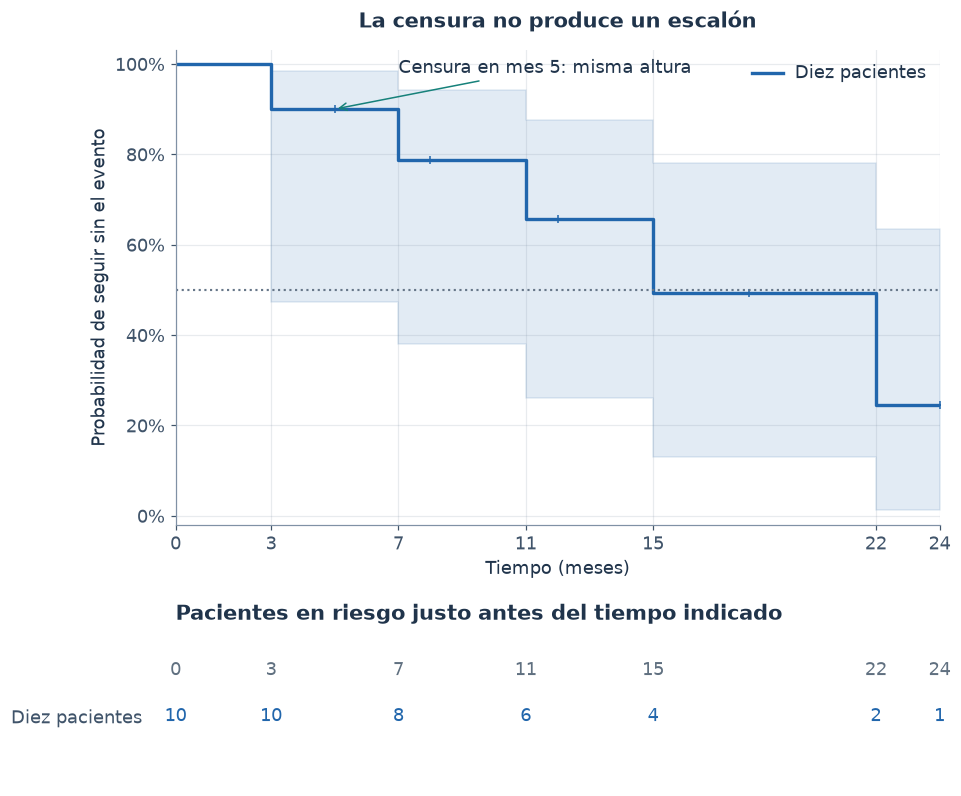

*Figura 01_km_anotada. Escalones: muertes; cruces: censuras; banda: IC95 % puntual. La banda no es un intervalo para cada paciente.*

In [8]:
BLOQUE='01-03'
PDF_REF='2.2.2'
km=KaplanMeierFitter(label='Leucemia · ejemplo didáctico').fit(pacientes.tiempo,pacientes.evento)
et=km.event_table.copy()
paso=et.loc[et.index>0,['at_risk','observed','censored']].rename(columns={'at_risk':'En riesgo antes','observed':'Muertes','censored':'Censuras'})
paso['S(t)']=km.survival_function_.iloc[:,0].reindex(paso.index)
paso=paso.rename_axis('Mes').reset_index()
tabla(paso,'01_tabla_km','No se redondea durante el cálculo; se muestran tres decimales, CSV conserva precisión.')
assert np.isclose(km.predict(7),.7875) and np.isclose(km.predict(15),.4921875)
fig,ajustes=km_grupos(pacientes.assign(grupo='Diez pacientes'),'La censura no produce un escalón','meses',ticks=[0,3,7,11,15,22,24])
ax=fig.axes[0];ax.axhline(.5,color='#677789',ls=':',lw=1.4)
ax.annotate('Censura en mes 5: misma altura',xy=(5,.9),xytext=(7,.98),fontsize=10,arrowprops={'arrowstyle':'->','color':VERDE})
figura(fig,'01_km_anotada','Escalones: muertes; cruces: censuras; banda: IC95 % puntual. La banda no es un intervalo para cada paciente.')

### 👀 Dónde mirar e interpretar
Compara las filas de los meses 5 y 7 y sus alturas. La fila «en riesgo» se refiere al instante previo.

### 📝 Tu respuesta
¿Cuántos están en riesgo antes del mes 7?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Ocho: una muerte previa y una censura previa han terminado sus aportaciones al riesgo.

</details>

### 📖 Paper real · Clark
[10.1038/sj.bjc.6601118](https://pmc.ncbi.nlm.nih.gov/articles/PMC2394262/)

Tutorial metodológico, no ensayo de eficacia. Censurar conserva el seguimiento conocido; los escalones ocurren en eventos.

**Qué mirar:** Secciones Censoring makes survival analysis different y Estimating the survival function; figuras 1–2. No se reutilizan estimaciones de pacientes del artículo.

**Pregunta:** ¿Por qué no eliminar a quienes terminan el seguimiento sin evento?

<details><summary>Orientación</summary>

Aportan información hasta su último tiempo conocido.

</details>

*Texto completo y leyendas consultados. Ejemplo histórico; no recomendación terapéutica actual.*

<a id="01-04"></a>
## 01-04 · Supervivencia a un horizonte

**Puente al PDF:** [apartado 2.2.3](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-2-3). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Cómo lees una curva en un horizonte clínico?

**Antes de ejecutar.** Busca 12 en el eje horizontal y sube hasta el escalón.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

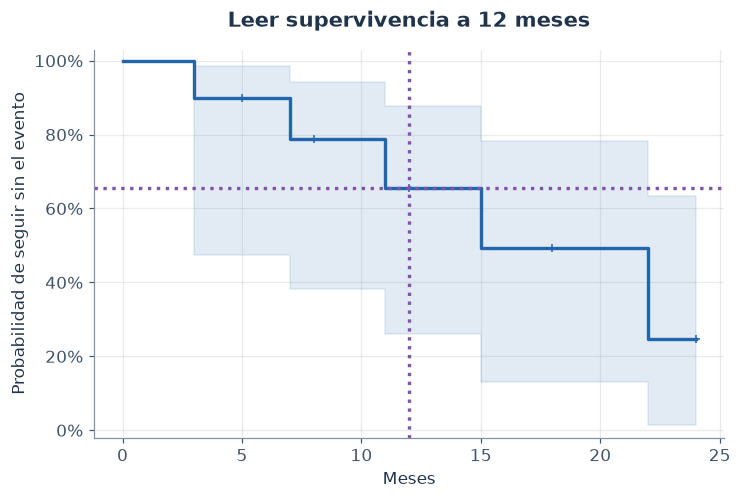

*Figura 01_horizonte. Lee tiempo → curva → probabilidad. Diez pacientes ficticios.*

In [9]:
BLOQUE='01-04'
PDF_REF='2.2.3'
ap_d=pacientes.copy();ap_k=km;ap_s=float(km.predict(12));ap_ci=km.confidence_interval_.loc[:12].iloc[-1]
fig,ax=plt.subplots(figsize=(7,4.8));curva(ax,km);ax.axvline(12,color=MORADO,ls=':');ax.axhline(ap_s,color=MORADO,ls=':');ax.set(xlabel='Meses',title='Leer supervivencia a 12 meses');ax.legend().remove();fig.tight_layout();figura(fig,'01_horizonte','Lee tiempo → curva → probabilidad. Diez pacientes ficticios.')

### 👀 Dónde mirar e interpretar
El horizonte debe tener sentido clínico y quedar dentro del seguimiento disponible.

### 📝 Tu respuesta
¿Puedes describir supervivencia a 36 meses con esta muestra?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

No hay seguimiento suficiente para estimarla sin extrapolar.

</details>

<a id="01-05"></a>
## 01-05 · Mediana alcanzada y no alcanzada

**Puente al PDF:** [apartado 2.2.4](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-2-4). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Cuándo ha ocurrido el evento en la mitad estimada?

**Antes de ejecutar.** Busca la primera llegada al 50%; puede no existir en el tramo observado.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

**Mediana de supervivencia:** primer tiempo en que la curva llega al 50% o baja de él. «No alcanzada» significa que el seguimiento no permite localizar ese punto; no significa supervivencia infinita.

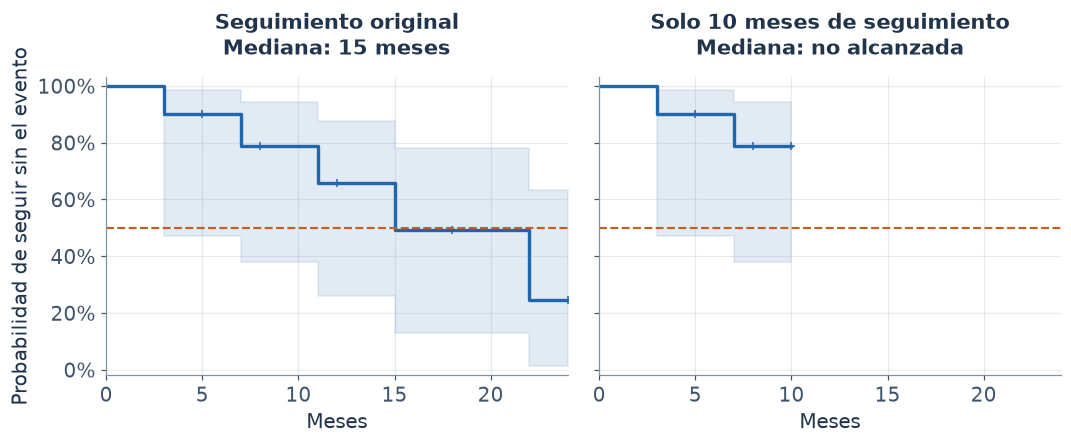

*Figura 01_mediana_alcanzada. Mismos pacientes y diferente duración disponible: no se inventa una mediana en el segundo panel.*

In [10]:
BLOQUE='01-05'
PDF_REF='2.2.4'
# Mismo caso observado solo hasta el mes 10.
corto=pacientes.assign(tiempo=np.minimum(pacientes.tiempo,10),evento=((pacientes.evento==1)&(pacientes.tiempo<=10)).astype(int))
kc=KaplanMeierFitter(label='Corte administrativo a 10 meses').fit(corto.tiempo,corto.evento)
assert np.isinf(kc.median_survival_time_)
fig,axes=plt.subplots(1,2,figsize=(10,4.3),sharey=True)
for ax,k,titulo in zip(axes,[km,kc],['Seguimiento original\nMediana: 15 meses','Solo 10 meses de seguimiento\nMediana: no alcanzada']):
    curva(ax,k);ax.axhline(.5,color=NARANJA,ls='--',lw=1.4);ax.set(xlabel='Meses',xlim=(0,24));ax.set_title(titulo,fontsize=12);ax.get_legend().remove()
fig.tight_layout();figura(fig,'01_mediana_alcanzada','Mismos pacientes y diferente duración disponible: no se inventa una mediana en el segundo panel.')

### 👀 Dónde mirar e interpretar
Los mismos pacientes dan mediana 15 meses con todo el seguimiento y no alcanzada con corte a 10.

### 📝 Tu respuesta
¿Por qué no dar 10 como mediana en el segundo panel?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

El 50% no se ha alcanzado; el corte no es una mediana.

</details>

### 📖 Paper real · CheckMate
[10.1056/NEJMoa1507643](https://pubmed.ncbi.nlm.nih.gov/26412456/)

Ensayo faseIII aleatorizado; cáncer pulmonar no escamoso avanzado tras platino. PFS: mediana 2.3 meses nivolumab y 4.2 docetaxel; a 1 año 19% y 8%.

**Qué mirar:** Resumen Results; figura 1D para PFS. No confundir con OS primario; HR OS usa IC 96%; no fabricar IC PFS desde cifras del resumen.

**Pregunta:** ¿La mediana y el horizonte ordenan necesariamente igual los tratamientos?

<details><summary>Orientación</summary>

No: describen partes distintas del seguimiento. Distinguir PFS de OS.

</details>

*Resumen original y leyendas; texto editorial localizado. Ejemplo histórico; no recomendación terapéutica actual.*

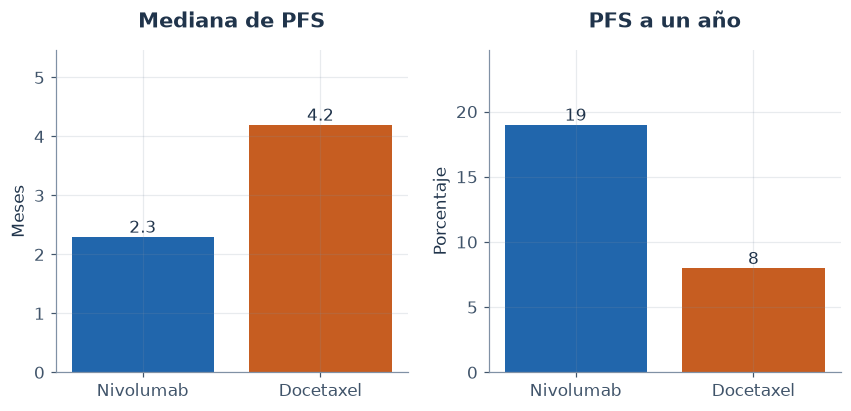

*Figura 01_checkmate_agregados. Figura docente propia de Borghaei2015, doi:10.1056/NEJMoa1507643. Dos resúmenes publicados; no son curvas reconstruidas ni incluyen IC no disponibles en el resumen.*

In [11]:
BLOQUE='01-05'
PDF_REF='2.2.4'
contexto('CheckMate057 publicado','Progresión o muerte','meses / porcentaje a1 año','Agregados del resumen original; figura docente propia')
fig,axs=plt.subplots(1,2,figsize=(8,4));
for ax,vals,title,unit in [(axs[0],[2.3,4.2],'Mediana de PFS','Meses'),(axs[1],[19,8],'PFS a un año','Porcentaje')]:
 ax.bar(['Nivolumab','Docetaxel'],vals,color=[AZUL,NARANJA]);ax.set(title=title,ylabel=unit);ax.set_ylim(0,max(vals)*1.3)
 for j,v in enumerate(vals):ax.text(j,v,f'{v:g}',ha='center',va='bottom')
fig.tight_layout();figura(fig,'01_checkmate_agregados','Figura docente propia de Borghaei2015, doi:10.1056/NEJMoa1507643. Dos resúmenes publicados; no son curvas reconstruidas ni incluyen IC no disponibles en el resumen.')

<a id="01-06"></a>
## 01-06 · Incertidumbre e IC 95 %

**Puente al PDF:** [apartado 2.2.5](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-2-5). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Con cuánta precisión estimamos la supervivencia?

**Antes de ejecutar.** Una estimación central idéntica puede tener incertidumbre diferente.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

Un **intervalo de confianza (IC)** expresa la precisión de una estimación bajo el método y sus supuestos. Más ancho significa mayor incertidumbre. No contiene al 95% de los pacientes ni garantiza que todos tengan ese pronóstico.

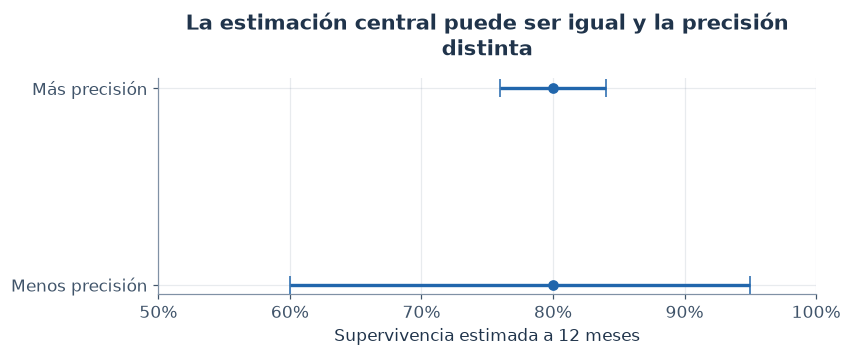

*Figura 01_precision_ic. Esquema: ambos puntos son 80 %; intervalos ilustrativos 76–84 % y 60–95 %. No corresponden a dos estudios ejecutados.*

In [12]:
BLOQUE='01-06'
PDF_REF='2.2.5'
contexto('Precisión de una estimación','Supervivencia a 12 meses','probabilidad',
         'Intervalos hipotéticos elegidos para ilustrar amplitud; no estimados de pacientes')
fig,ax=plt.subplots(figsize=(8,3.5))
ax.errorbar([.8,.8],[1,0],xerr=[[.04,.2],[.04,.15]],fmt='o',capsize=6,color=AZUL)
ax.set(xlim=(.5,1),yticks=[1,0],yticklabels=['Más precisión','Menos precisión'],xlabel='Supervivencia estimada a 12 meses',
       title='La estimación central puede ser igual y la precisión distinta')
ax.xaxis.set_major_formatter(PercentFormatter(1));fig.tight_layout()
figura(fig,'01_precision_ic','Esquema: ambos puntos son 80 %; intervalos ilustrativos 76–84 % y 60–95 %. No corresponden a dos estudios ejecutados.')

In [13]:
BLOQUE='01-06'
PDF_REF='2.2.5'
contexto('Diez pacientes ficticios','Muerte','meses','Misma cohorte docente')
tabla(resumen_km({'Diez pacientes':km},12),'01_resumen_km','S12 e IC95% puntual; no intervalo individual.')

Grupo,N,Eventos,Censuras,Horizonte,S(t),IC95 inferior,IC95 superior,Mediana
Diez pacientes,10,5,5,12,0.656,0.260,0.876,15.00


*Tabla 01_resumen_km. S12 e IC95% puntual; no intervalo individual.*

### 👀 Dónde mirar e interpretar
Lee punto y dos límites; distingue el esquema hipotético de la tabla de pacientes.

### 📝 Tu respuesta
¿Qué conclusión sería excesiva con un intervalo ancho?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Afirmar una probabilidad muy precisa o prometer el resultado de una persona.

</details>

<a id="01-07"></a>
## 01-07 · Probabilidad acumulada y complemento

**Puente al PDF:** [apartado 2.3.1](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-3-1). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Qué parte ha presentado muerte al horizonte?

**Antes de ejecutar.** Con un único evento, seguir vivo y haber muerto son complementarios.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

Paciente,tiempo,evento,Fin
1,3,1,Muerte
6,5,0,Pérdida de contacto
7,8,0,Fin administrativo


*Tabla 01_tres_historias. Tres filas originales: una muerte, una pérdida y un fin administrativo.*

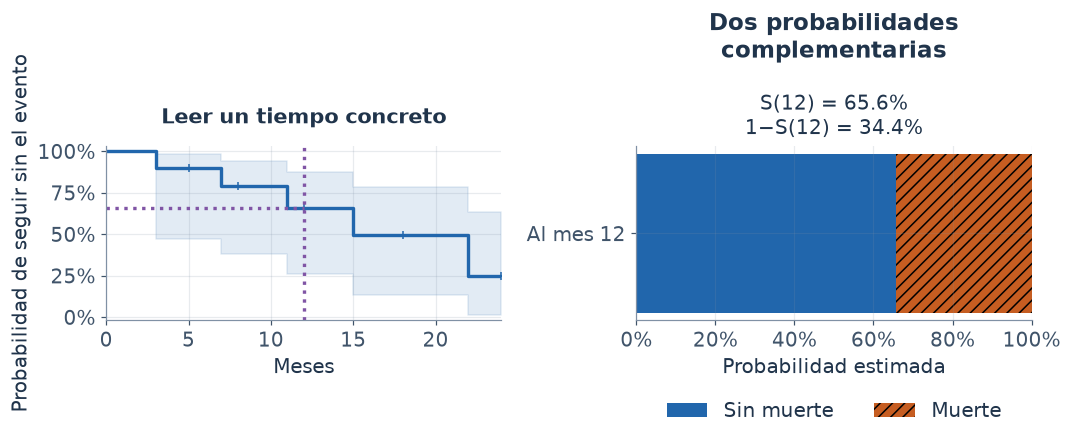

*Figura 01_leer_probabilidad. Mismos diez pacientes. La banda izquierda es IC95 % puntual; la barra derecha muestra probabilidades, no recuentos brutos.*

In [14]:
BLOQUE='01-07'
PDF_REF='2.3.1'
contexto('Apoyos de los diez pacientes','Muerte desde diagnóstico','meses',
         'Mismos diez pacientes ficticios del bloque 01-01; esquemas identificados por separado')
ap_d=pd.read_csv(OUT/'01_datos_leucemia.csv')
ap_k=KaplanMeierFitter().fit(ap_d.tiempo,ap_d.evento)
tabla(ap_d.iloc[[0,5,6]],'01_tres_historias','Tres filas originales: una muerte, una pérdida y un fin administrativo.')
ap_s=float(ap_k.predict(12));ap_ci=ap_k.confidence_interval_.loc[:12].iloc[-1]
fig,axs=plt.subplots(1,2,figsize=(10,4.6))
curva(axs[0],ap_k);axs[0].axvline(12,color=MORADO,ls=':')
axs[0].plot([0,12],[ap_s,ap_s],color=MORADO,ls=':')
axs[0].set(title='Leer un tiempo concreto',xlabel='Meses',xlim=(0,24))
axs[0].legend().remove()
axs[1].barh(['Al mes 12'],[ap_s],color=AZUL,label='Sin muerte')
axs[1].barh(['Al mes 12'],[1-ap_s],left=[ap_s],color=NARANJA,hatch='///',label='Muerte')
axs[1].set(xlim=(0,1),xlabel='Probabilidad estimada',title='Dos cantidades complementarias')
axs[1].xaxis.set_major_formatter(PercentFormatter(1));axs[1].legend(loc='lower center',bbox_to_anchor=(.5,-.42))
axs[1].text(.5,.9,f'S(12) = {ap_s:.1%}\n1−S(12) = {1-ap_s:.1%}',transform=axs[1].transAxes,ha='center')
fig.tight_layout()
figura(fig,'01_leer_probabilidad','Mismos diez pacientes. La banda izquierda es IC95 % puntual; la barra derecha muestra probabilidades, no recuentos brutos.')

### 👀 Dónde mirar e interpretar
1−S(12) es la probabilidad acumulada de muerte. Con causas competidoras la pregunta requiere 03-03.

### 📝 Tu respuesta
Expresa ambas probabilidades y su suma.

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

65.6% y 34.4%, aproximadamente 100%. No son porcentajes de filas al cierre.

</details>

<a id="01-08"></a>
## 01-08 · Hazard: intensidad entre quienes siguen en riesgo

**Puente al PDF:** [apartado 2.3.2](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-3-2). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Puede bajar la tasa de muerte y continuar bajando la supervivencia?

**Antes de ejecutar.** La intensidad entre quienes siguen vivos difiere de la probabilidad acumulada.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

El **hazard** es la intensidad del evento entre quienes siguen en riesgo; se expresa por unidad de tiempo. No es una probabilidad instantánea. Una intensidad puede subir o bajar; S(t) no aumenta.

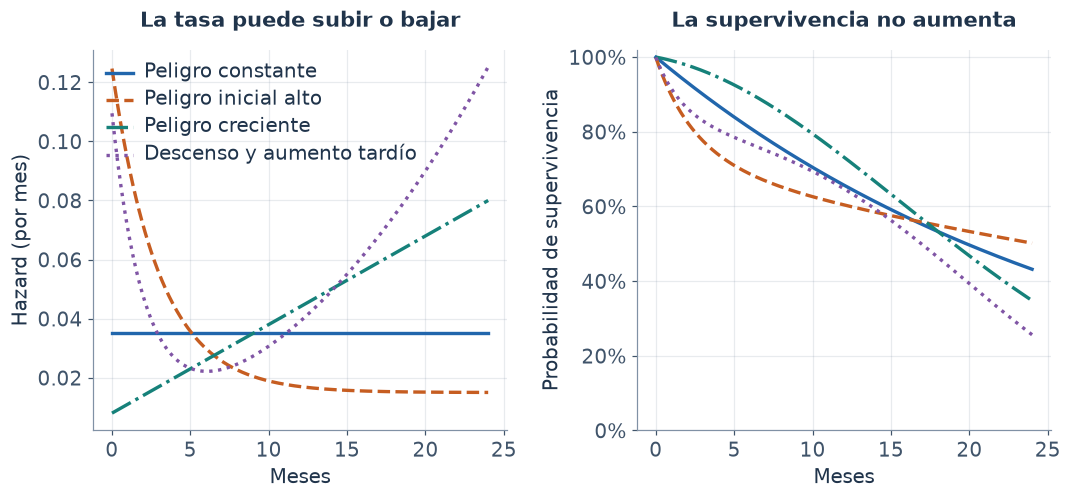

*Figura 01_hazard_supervivencia. Cuatro modelos teóricos sanitarios, incluido descenso seguido de aumento (forma de bañera). No son estimaciones de mortalidad infantil ni de una población real.*

In [15]:
BLOQUE='01-08'
PDF_REF='2.3.2'
contexto('Patrones teóricos de mortalidad','Muerte','meses','Curvas teóricas declaradas')
t=np.linspace(.01,24,500)
perfiles=[('Peligro constante',np.full_like(t,.035),.035*t),
          ('Peligro inicial alto',.11*np.exp(-t/3)+.015,.33*(1-np.exp(-t/3))+.015*t),
          ('Peligro creciente',.008+.003*t,.008*t+.0015*t*t),
          ('Descenso y aumento tardío',.1*np.exp(-t/2)+.01+.0002*t*t,.2*(1-np.exp(-t/2))+.01*t+(.0002/3)*t**3)]
fig,axes=plt.subplots(1,2,figsize=(10,4.8))
for j,(label,h,H) in enumerate(perfiles):
    axes[0].plot(t,h,color=COLORES[j],ls=ESTILOS[j],label=label)
    axes[1].plot(t,np.exp(-H),color=COLORES[j],ls=ESTILOS[j],label=label)
axes[0].set(title='La tasa puede subir o bajar',xlabel='Meses',ylabel='Hazard (por mes)')
axes[1].set(title='La supervivencia no aumenta',xlabel='Meses',ylabel='Probabilidad de supervivencia',ylim=(0,1.02))
axes[1].yaxis.set_major_formatter(PercentFormatter(1));axes[0].legend(fontsize=9);fig.tight_layout()
figura(fig,'01_hazard_supervivencia','Cuatro modelos teóricos sanitarios, incluido descenso seguido de aumento (forma de bañera). No son estimaciones de mortalidad infantil ni de una población real.')

### 👀 Dónde mirar e interpretar
Sigue un mismo color en ambos paneles. Son modelos hipotéticos.

### 📝 Tu respuesta
¿Hazard 0.1 por mes significa exactamente 10% de probabilidad mensual?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

No. Una tasa no es una probabilidad; relacionarlas requiere considerar el intervalo y el modelo.

</details>

<a id="01-09"></a>
## 01-09 · HR: referencia, dirección, unidad e intervalo

**Puente al PDF:** [apartado 2.3.3](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-3-3). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Cómo lees un HR y su referencia?

**Antes de ejecutar.** Compara intensidades para el mismo evento; indica siempre a quién se compara con quién.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

El **hazard ratio (HR)** compara dos intensidades. HR 0.70 significa una tasa 30% menor para el grupo del numerador respecto al de referencia, bajo el modelo. No significa 30 puntos menos de probabilidad. En edad, hay que declarar si el cambio es por 1 o por 10 años. Su IC se compara con 1, valor de ausencia de asociación en esa escala.

In [16]:
BLOQUE='01-09'
PDF_REF='2.3.3'
contexto('Lectura del HR','Muerte','HR','Ejemplos hipotéticos, sin datos de pacientes')
tabla(pd.DataFrame({'Comparación':['B respecto a A','B respecto a A','Edad:10 años más'],'HR':[.7,1.2,1.3],'Lectura':['Tasa30% menor','Tasa20% mayor','Tasa30% mayor por10 años']}),'01_hr_lectura','Ejemplos teóricos. Interpretación favorable depende del evento.')

Comparación,HR,Lectura
B respecto a A,0.700,Tasa30% menor
B respecto a A,1.200,Tasa20% mayor
Edad:10 años más,1.300,Tasa30% mayor por10 años


*Tabla 01_hr_lectura. Ejemplos teóricos. Interpretación favorable depende del evento.*

### 👀 Dónde mirar e interpretar
Primero evento y referencia; después punto e intervalo si está disponible.

### 📝 Tu respuesta
¿HR 0.70 prueba por sí solo que se evitan 30 muertes por 100 pacientes?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

No: falta el riesgo basal, horizonte, incertidumbre y justificación causal.

</details>

<a id="01-10"></a>
## 01-10 · Mismo HR, distinto riesgo basal y diferencia absoluta

**Puente al PDF:** [apartado 2.3.4](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-3-4). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿El mismo HR implica igual diferencia absoluta?

**Antes de ejecutar.** Compara dos riesgos basales al mismo horizonte.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

Población,HR,Riesgo sin intervención (%),Riesgo con intervención (%),Diferencia absoluta (puntos %)
Menor riesgo basal,0.700,5.000,3.527,1.473
Mayor riesgo basal,0.700,40.000,30.063,9.937


*Tabla 01_hr_absoluto. Modelo proporcional teórico; no se calculan IC porque son cantidades teóricas.*

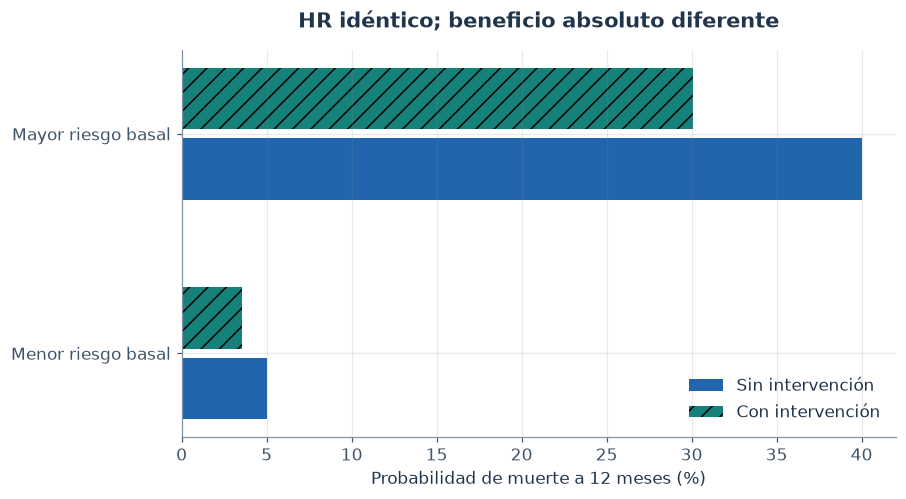

*Figura 01_hr_riesgo_absoluto. Un HR no determina por sí solo cuántas muertes se evitarían: falta el riesgo basal y el horizonte.*

In [17]:
BLOQUE='01-10'
PDF_REF='2.3.4'
contexto('HR y riesgo basal','Muerte','meses','Dos modelos teóricos de riesgos proporcionales',HR=.7,horizonte=12)
s0=np.array([.95,.60]);s1=s0**.7
abs_tab=pd.DataFrame({'Población':['Menor riesgo basal','Mayor riesgo basal'],'HR':[.7,.7],
    'Riesgo sin intervención (%)':100*(1-s0),'Riesgo con intervención (%)':100*(1-s1),
    'Diferencia absoluta (puntos %)':100*(s1-s0)})
tabla(abs_tab,'01_hr_absoluto','Modelo proporcional teórico; no se calculan IC porque son cantidades teóricas.')
fig,ax=plt.subplots(figsize=(8.5,4.8));y=np.arange(2)
ax.barh(y-.16,100*(1-s0),height=.28,color=AZUL,label='Sin intervención')
ax.barh(y+.16,100*(1-s1),height=.28,color=VERDE,hatch='//',label='Con intervención')
ax.set(yticks=y,yticklabels=abs_tab.Población,xlabel='Probabilidad de muerte a 12 meses (%)',title='HR idéntico; beneficio absoluto diferente')
ax.legend();fig.tight_layout();figura(fig,'01_hr_riesgo_absoluto','Un HR no determina por sí solo cuántas muertes se evitarían: falta el riesgo basal y el horizonte.')

### 👀 Dónde mirar e interpretar
Compara las diferencias en puntos porcentuales de la tabla.

### 📝 Tu respuesta
¿Dónde hay más diferencia absoluta?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

En el ejemplo de mayor riesgo basal. Un HR aislado no basta para cuantificar magnitud absoluta.

</details>

### 📖 Paper real · BIG
[10.1056/NEJMoa052258](https://pubmed.ncbi.nlm.nih.gov/16382061/)

Ensayo aleatorizado faseIII, mujeres posmenopáusicas con cáncer de mama hormonodependiente. DFS a 5 años:84.0% letrozol,81.4% tamoxifeno; HR 0.81 IC 95%0.70–0.93; diferencia aritmética 2.6 puntos.

**Qué mirar:** Resumen Methods/Results. IC del HR 95%; el resumen no da IC de diferencia absoluta: no inventarlo.

**Pregunta:** ¿19% relativo equivale a 19 puntos porcentuales?

<details><summary>Orientación</summary>

No:84.0−81.4=2.6 puntos; HR y probabilidad responden preguntas distintas.

</details>

*Resumen original; editorial bloqueada 403. Ejemplo histórico; no recomendación terapéutica actual.*

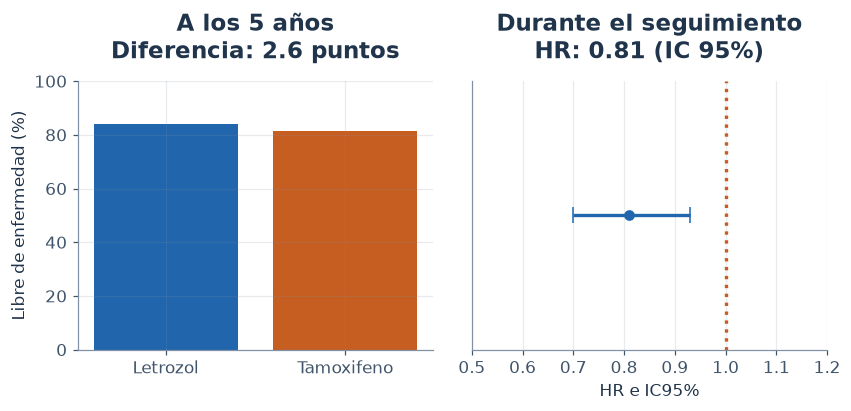

*Figura 01_big_agregados. Figura docente propia de BIG1-98(2005), doi:10.1056/NEJMoa052258. Diferencia aritmética2.6pp; IC de esta diferencia no disponible aquí. No reproduce figuras del artículo.*

In [18]:
BLOQUE='01-10'
PDF_REF='2.3.4'
contexto('BIG1-98 publicado','Fin del periodo libre de enfermedad','Porcentaje a5 años y HR','Agregados del resumen2005; figura docente propia')
fig,axs=plt.subplots(1,2,figsize=(8,4));axs[0].bar(['Letrozol','Tamoxifeno'],[84,81.4],color=[AZUL,NARANJA]);axs[0].set(ylim=(0,100),ylabel='Libre de enfermedad (%)',title='A los5 años: diferencia2.6 puntos');axs[1].errorbar([.81],[0],xerr=[[.11],[.12]],fmt='o',capsize=5,color=AZUL);axs[1].axvline(1,ls=':',color=NARANJA);axs[1].set(yticks=[],xlim=(.5,1.2),xlabel='HR e IC95%',title='Durante seguimiento: HR0.81');fig.tight_layout();figura(fig,'01_big_agregados','Figura docente propia de BIG1-98(2005), doi:10.1056/NEJMoa052258. Diferencia aritmética2.6pp; IC de esta diferencia no disponible aquí. No reproduce figuras del artículo.')

<a id="01-11"></a>
## 01-11 · ¿Qué pregunta quiero responder? Mapa de decisión, sin desarrollar log-rank ni p-valor

**Puente al PDF:** [apartado 2.4](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-4). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Qué pregunta quiero responder?

**Antes de ejecutar.** Elige la pregunta antes de la herramienta; las tres no son equivalentes.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

| Pregunta | Salida principal | Continuación |
|---|---|---|
| Supervivencia/diferencia a un horizonte | S(t), diferencia absoluta e IC |02-04|
| Comparación global de curvas |Log-rank|02-05|
| Asociación ajustada por covariables |Cox|02-07/08|

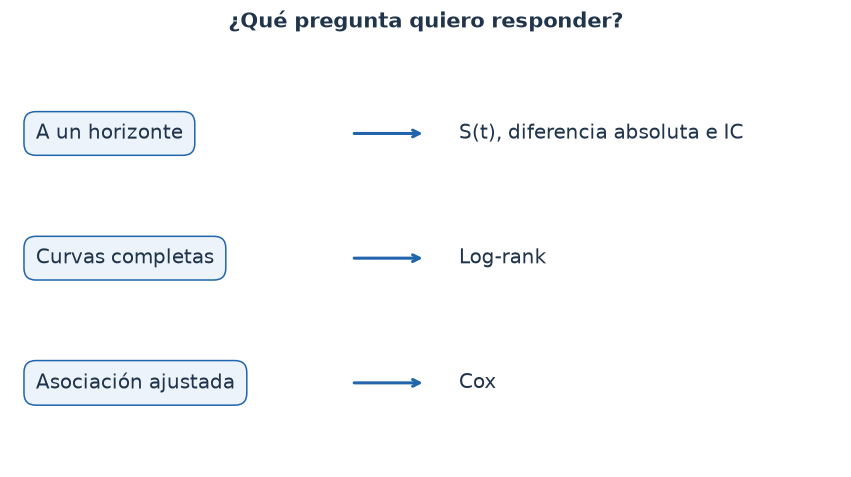

*Figura 01_mapa_decision. Orientación: horizonte, comparación global o ajuste. La explicación del log-rank está en el caso real02-05.*

In [19]:
BLOQUE='01-11'
PDF_REF='2.4'
contexto('Mapa de decisión','Según la pregunta clínica','No aplica','Orientación docente, sin datos ni contraste')
fig,ax=plt.subplots(figsize=(8,4.6));ax.axis('off')
for y,q,r in [(0.8,'A un horizonte','S(t), diferencia absoluta e IC'),(.5,'Curvas completas','Log-rank'),(.2,'Asociación ajustada','Cox')]:
 ax.text(.03,y,q,transform=ax.transAxes,fontsize=13,va='center',bbox=dict(boxstyle='round,pad=.6',fc='#edf3fa',ec=AZUL));ax.annotate('',xy=(.50,y),xytext=(.41,y),xycoords='axes fraction',arrowprops=dict(arrowstyle='->',lw=2,color=AZUL));ax.text(.54,y,r,transform=ax.transAxes,fontsize=13,va='center')
ax.set_title('¿Qué pregunta quiero responder?');figura(fig,'01_mapa_decision','Orientación: horizonte, comparación global o ajuste. La explicación del log-rank está en el caso real02-05.')

### 👀 Dónde mirar e interpretar
Este mapa solo orienta. La explicación del log-rank se hace sobre colon.

### 📝 Tu respuesta
¿Qué eliges para comparar supervivencia a 5 años?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

S(5) y diferencia absoluta con IC; el contraste global responde otra pregunta.

</details>

<a id="01-A1"></a>
## 🌱 Opcional · 01-A1 · Apéndice matemático: KM, Greenwood, Cox, log-rank, transformaciones

**Puente al PDF:** [apartado A](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-A). En Colab puedes localizarlo por su número.

**Pregunta clínica.** Ampliación: ¿cómo se calculan los estimadores?

**Antes de ejecutar.** Puedes omitir todo este apéndice en la primera lectura.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

### 🌱 Las fórmulas, después de la idea

Para un tiempo continuo $T$: $S(t)=P(T>t)$, $F(t)=1-S(t)$ y $f(t)=-S'(t)$.
La **densidad** $f$ no es el hazard: $h(t)=f(t)/S(t)$, $H(t)=\int_0^t h(u)\,du$ y $S(t)=e^{-H(t)}$.
Estas identidades son poblacionales; con eventos competitivos, $1-S$ para cualquier evento no equivale a incidencia de una causa concreta.

Con $n_j$ pacientes en riesgo y $d_j$ eventos en el instante $t_j$:

$$\widehat S(t)=\prod_{t_j\leq t}\left(1-\frac{d_j}{n_j}\right).$$

Greenwood acumula la variabilidad de cada escalón:

$$\widehat{\mathrm{Var}}[\widehat S(t)]=\widehat S(t)^2\sum_{t_j\leq t}\frac{d_j}{n_j(n_j-d_j)}.$$

El producto multiplica las fracciones de supervivencia; la suma acumula contribuciones a la variabilidad. La aproximación de IC depende del tamaño y seguimiento. El caso límite $n_j=d_j$ requiere tratamiento específico; no dividir entre cero.

La censura a la derecha en el tiempo $c$ aporta $T>c$, no el valor de $T$. El modelo requiere que la censura sea independiente del evento en la población/estratos analizados, o condicionada a las covariables pertinentes.

## 🌱 Fundamentos opcionales de log-rank y Cox

**Log-rank:** en cada instante de evento, si $d_j$ eventos ocurren entre $n_j$ personas, el grupo 1 espera $E_{1j}=d_j n_{1j}/n_j$, donde $n_{1j}$ son sus pacientes en riesgo. Acumula observados ($O$) menos esperados ($E$), y su varianza hipergeométrica $V$. Para dos grupos, $Z=(\sum_j O_{1j}-\sum_j E_{1j})/\sqrt{V}$; $Z^2$ se aproxima a una distribución chi-cuadrado con un grado de libertad bajo la hipótesis nula y sus condiciones. La aproximación no es exacta para cualquier muestra pequeña.

**Cox:** $h(t\mid X)=h_0(t)\exp(\beta^\top X)$. $X$ representa las covariables y $\beta$ sus coeficientes; el superíndice expresa la suma de coeficiente por covariable. El hazard basal $h_0$ varía con el tiempo; el HR entre perfiles fijos es constante bajo proporcionalidad. $\exp(\beta_k)$ es el HR por la unidad definida de la covariable $k$, manteniendo las demás constantes en un modelo sin interacciones. No exige normalidad de las covariables. Sí necesita una forma funcional adecuada y tratar la dependencia si existe.

**Verosimilitud parcial:** compara quién presentó el evento con quienes estaban en riesgo entonces:

$$L(\beta)=\prod_{i:\,\text{evento}}\frac{\exp(\beta^\top X_i)}{\sum_{j\in R(t_i)}\exp(\beta^\top X_j)}.$$

$R(t_i)$ es el conjunto de pacientes en riesgo cuando ocurre el evento de $i$. La fórmula está escrita para eventos sin empates. El ajuste ejecutado gestiona empates con el método de Efron. No es necesario optimizar esta fórmula a mano.

**Sesgos y límites:** ajuste no elimina automáticamente confusión no medida; seleccionar casos completos puede cambiar la población. Comprobar la censura y la definición estable del evento es tan necesario como obtener un p-valor.

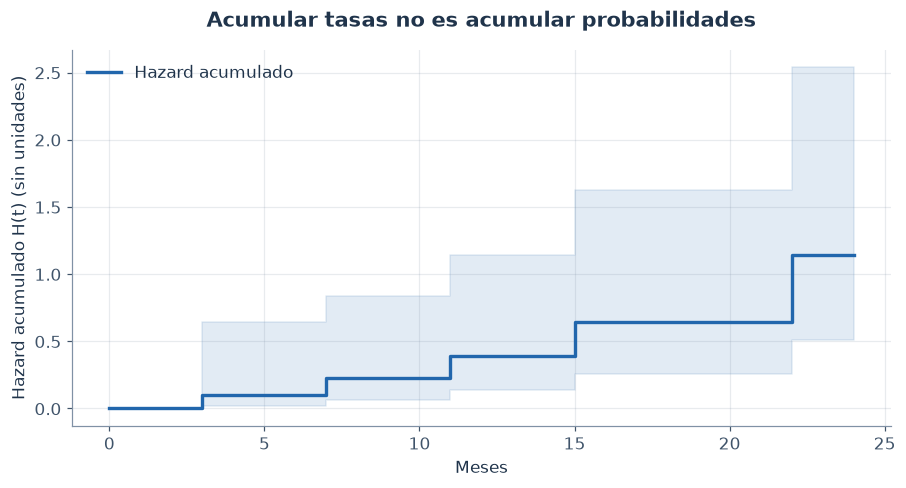

*Figura 01_nelson_aalen. Nelson–Aalen e IC95 %. H(t) puede ser mayor que uno; no representa más del 100 % de pacientes.*

Mes,H(t) Nelson–Aalen,S(t) Kaplan–Meier,exp(−H estimado)
3,0.100,0.900,0.905
7,0.225,0.788,0.799
11,0.392,0.656,0.676
15,0.642,0.492,0.526
22,1.142,0.246,0.319


*Tabla 01_km_nelson. La identidad poblacional no hace idénticos los dos estimadores en muestras pequeñas.*

In [20]:
BLOQUE='01-A1'
PDF_REF='A'
contexto('Diez pacientes con leucemia','Muerte por cualquier causa','meses','Simulación didáctica fija; ejemplo del PDF',N=10)
na=NelsonAalenFitter(nelson_aalen_smoothing=False).fit(pacientes.tiempo,pacientes.evento,label='Hazard acumulado')
fig,ax=plt.subplots(figsize=(8.5,4.7));na.plot_cumulative_hazard(ax=ax,ci_alpha=.13,color=AZUL)
ax.set(title='Acumular tasas no es acumular probabilidades',xlabel='Meses',ylabel='Hazard acumulado H(t) (sin unidades)');fig.tight_layout()
figura(fig,'01_nelson_aalen','Nelson–Aalen e IC95 %. H(t) puede ser mayor que uno; no representa más del 100 % de pacientes.')
comp=pd.DataFrame({'Mes':[3,7,11,15,22]})
comp['H(t) Nelson–Aalen']=[float(na.predict(t)) for t in comp.Mes]
comp['S(t) Kaplan–Meier']=[float(km.predict(t)) for t in comp.Mes]
comp['exp(−H estimado)']=np.exp(-comp['H(t) Nelson–Aalen'])
tabla(comp,'01_km_nelson','La identidad poblacional no hace idénticos los dos estimadores en muestras pequeñas.')

In [21]:
BLOQUE='01-A1'
PDF_REF='A'
contexto('Diez pacientes con leucemia','Muerte por cualquier causa','meses','Simulación didáctica fija',N=10)
ev=km.event_table.query('observed > 0').copy()
ev['Aporte Greenwood']=ev.observed/(ev.at_risk*(ev.at_risk-ev.observed))
ev['S(t)']=km.survival_function_.iloc[:,0].reindex(ev.index)
ev['Varianza estimada']=ev['S(t)']**2*ev['Aporte Greenwood'].cumsum()
tabla(ev[['at_risk','observed','S(t)','Varianza estimada']].rename(columns={'at_risk':'En riesgo','observed':'Muertes'}).rename_axis('Mes').reset_index(),
      '01_greenwood','Varianza estimada de S(t); los IC de las figuras usan transformación log-log para respetar los límites 0 y 1.')

Mes,En riesgo,Muertes,S(t),Varianza estimada
3.000,10,1,0.900,0.009
7.000,8,1,0.788,0.018
11.000,6,1,0.656,0.027
15.000,4,1,0.492,0.035
22.000,2,1,0.246,0.039


*Tabla 01_greenwood. Varianza estimada de S(t); los IC de las figuras usan transformación log-log para respetar los límites 0 y 1.*

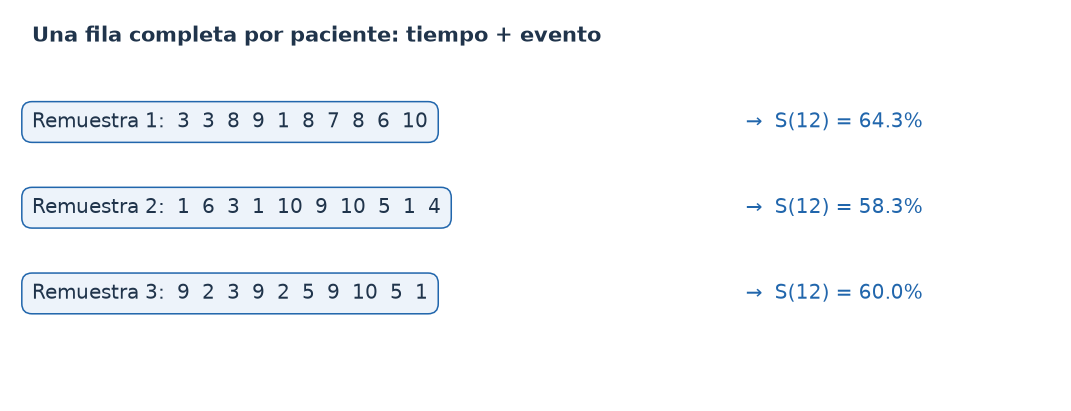

*Figura 01_bootstrap_esquema. Identificadores repetidos porque se muestrea con reemplazo. Se conservan tiempo y evento juntos; tres remuestras solo explican el procedimiento.*

Remuestra,IDs,S12
1,3 3 8 9 1 8 7 8 6 10,0.643
2,1 6 3 1 10 9 10 5 1 4,0.583
3,9 2 3 9 2 5 9 10 5 1,0.600


*Tabla 01_bootstrap_ejemplo. Remuestras ilustrativas, sin IC calculado con ellas.*

In [22]:
BLOQUE='01-A1'
PDF_REF='A'
contexto('Bootstrap de pacientes','Muerte desde diagnóstico','meses',
         'Tres remuestras ilustrativas de los diez pacientes; no bastan para un IC',semilla=20260919)
ap_rng=np.random.default_rng(20260919);ap_draws=[];ap_est=[]
for j in range(3):
    ix=ap_rng.integers(0,len(ap_d),len(ap_d));sample=ap_d.iloc[ix]
    ap_draws.append(sample.Paciente.tolist())
    ap_est.append(float(KaplanMeierFitter().fit(sample.tiempo,sample.evento).predict(12)))
fig,ax=plt.subplots(figsize=(10,4));ax.axis('off')
ax.text(.02,.92,'Una fila completa por paciente: tiempo + evento',weight='bold',fontsize=14)
for j,(ids,s) in enumerate(zip(ap_draws,ap_est)):
    ax.text(.02,.70-.22*j,f'Remuestra {j+1}:  '+ '  '.join(map(str,ids)),fontsize=12,
            bbox=dict(boxstyle='round,pad=.5',fc='#edf3fa',ec=AZUL))
    ax.text(.70,.70-.22*j,f'→  S(12) = {s:.1%}',fontsize=13,color=AZUL)
figura(fig,'01_bootstrap_esquema','Identificadores repetidos porque se muestrea con reemplazo. Se conservan tiempo y evento juntos; tres remuestras solo explican el procedimiento.')
tabla(pd.DataFrame({'Remuestra':[1,2,3],'IDs':[' '.join(map(str,x)) for x in ap_draws],'S12':ap_est}),
      '01_bootstrap_ejemplo','Remuestras ilustrativas, sin IC calculado con ellas.')

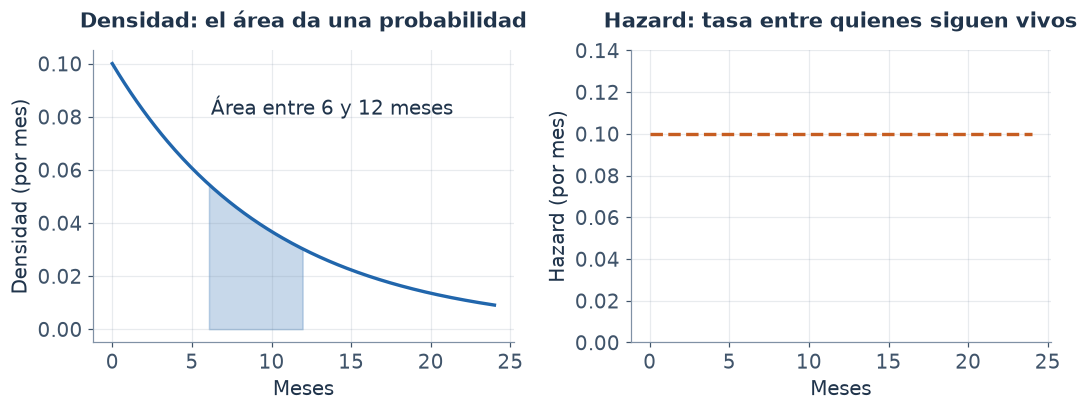

*Figura 01_densidad_hazard. Funciones teóricas. Densidad decreciente y hazard constante son compatibles: sus poblaciones de referencia son diferentes.*

In [23]:
BLOQUE='01-A1'
PDF_REF='A'
contexto('Densidad y hazard','Muerte hipotética','meses','Modelo exponencial teórico con hazard 0,1 por mes')
t=np.linspace(0,24,250);density=.1*np.exp(-.1*t)
fig,axs=plt.subplots(1,2,figsize=(10,4))
axs[0].plot(t,density,color=AZUL);axs[0].fill_between(t,0,density,where=(t>=6)&(t<=12),color=AZUL,alpha=.25)
axs[0].set(title='Densidad: el área da una probabilidad',xlabel='Meses',ylabel='Densidad (por mes)')
axs[0].text(.28,.78,'Área entre 6 y 12 meses',transform=axs[0].transAxes,fontsize=10)
axs[1].plot(t,np.full_like(t,.1),color=NARANJA,ls='--')
axs[1].set(title='Hazard: tasa entre quienes siguen vivos',xlabel='Meses',ylabel='Hazard (por mes)',ylim=(0,.14))
fig.tight_layout();figura(fig,'01_densidad_hazard','Funciones teóricas. Densidad decreciente y hazard constante son compatibles: sus poblaciones de referencia son diferentes.')

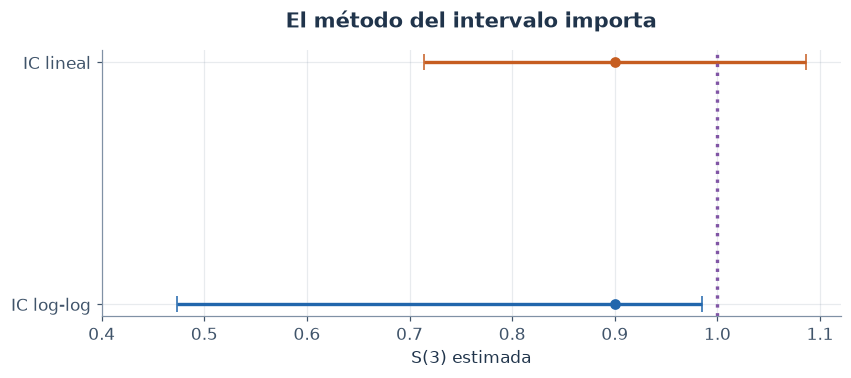

*Figura 01_ic_transformacion. Primer evento: S=0,9, Greenwood G=1/90. El intervalo lineal se muestra como contraste didáctico; el análisis usa log-log.*

In [24]:
BLOQUE='01-A1'
PDF_REF='A'
contexto('IC al primer evento','Muerte desde diagnóstico','probabilidad','Mismos diez pacientes; Greenwood al mes 3')
s=.9;g=1/(10*9);se=s*np.sqrt(g)
normal=(s-1.96*se,s+1.96*se)
gg=np.log(-np.log(s));ee=np.sqrt(g)/abs(np.log(s))
ll=(np.exp(-np.exp(gg+1.96*ee)),np.exp(-np.exp(gg-1.96*ee)))
fig,ax=plt.subplots(figsize=(8,3.7))
for y,pair,label,col in [(1,normal,'Lineal: puede superar 1',NARANJA),(0,ll,'Log-log: respeta 0–1',AZUL)]:
    ax.errorbar([s],[y],xerr=[[s-pair[0]],[pair[1]-s]],fmt='o',capsize=5,color=col)
ax.axvline(1,color=MORADO,ls=':');ax.set(yticks=[1,0],yticklabels=['IC lineal','IC log-log'],
    xlim=(.4,1.12),xlabel='S(3) estimada',title='El método del intervalo importa')
fig.tight_layout();figura(fig,'01_ic_transformacion','Primer evento: S=0,9, Greenwood G=1/90. El intervalo lineal se muestra como contraste didáctico; el análisis usa log-log.')

In [25]:
BLOQUE='01-A1'
PDF_REF='A'
ic_med=median_survival_times(km.confidence_interval_).copy()
ic_med.columns=['Límite inferior (meses)','Límite superior (meses)']
ic_med=ic_med.rename_axis('Cuantil').reset_index()
tabla(ic_med,'01_ic_mediana','IC95 % de la mediana por inversión de la banda de Kaplan–Meier; inf significa límite no estimable en este seguimiento, no supervivencia infinita.')

Cuantil,Límite inferior (meses),Límite superior (meses)
0.500,3.000,inf


*Tabla 01_ic_mediana. IC95 % de la mediana por inversión de la banda de Kaplan–Meier; inf significa límite no estimable en este seguimiento, no supervivencia infinita.*

**KM, cálculo manual opcional:** en cada evento se conserva la fracción sin evento de quienes estaban en riesgo y se multiplican las fracciones previas. En mes 3:9/10; en mes 7:9/10×7/8=0.7875. Greenwood aproxima varianza; el IC log-log mantiene límites entre 0 y 1. El bootstrap vuelve a tomar pacientes completos con reemplazo y repite la estimación; muchas repeticiones aproximan variabilidad, no corrigen sesgos del diseño.

<a id="01-A2"></a>
## 🌱 Opcional · 01-A2 · Ampliación clínica: supervivencia condicional

**Puente al PDF:** [apartado B.1](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-B-1). En Colab puedes localizarlo por su número.

**Pregunta clínica.** Si ha sobrevivido 6 meses, ¿cómo cambia la pregunta a 12?

**Antes de ejecutar.** Condicionar cambia la población de referencia.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

Cantidad,Estimación
S(6),0.900
S(12),0.656
S(12 | vivo a 6),0.729


*Tabla 01_condicional. Estimaciones Kaplan–Meier; no se ha calculado IC del cociente en este bloque.*

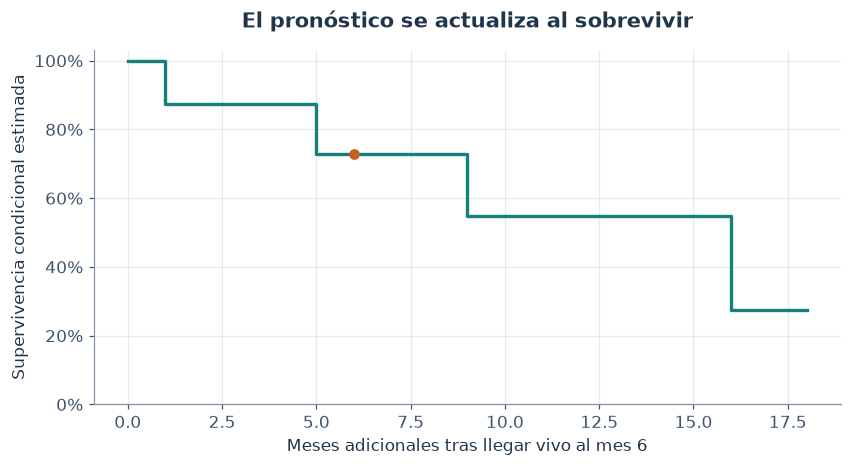

*Figura 01_supervivencia_condicional. Curva condicionada a sobrevivir seis meses. Ejemplo pequeño: estimación descriptiva, no consejo individual.*

In [26]:
BLOQUE='01-A2'
PDF_REF='B.1'
s6=float(km.predict(6));s12=float(km.predict(12));cond=s12/s6
tabla(pd.DataFrame({'Cantidad':['S(6)','S(12)','S(12 | vivo a 6)'],'Estimación':[s6,s12,cond]}),'01_condicional','Estimaciones Kaplan–Meier; no se ha calculado IC del cociente en este bloque.')
fig,ax=plt.subplots(figsize=(8,4.5))
xx=np.array([6,7,8,11,12,15,18,22,24]);yy=np.array([km.predict(x)/s6 for x in xx])
ax.step(xx-6,yy,where='post',color=VERDE);ax.scatter([6],[cond],color=NARANJA,zorder=3)
ax.set(title='El pronóstico se actualiza al sobrevivir',xlabel='Meses adicionales tras llegar vivo al mes 6',ylabel='Supervivencia condicional estimada',ylim=(0,1.03))
ax.yaxis.set_major_formatter(PercentFormatter(1));fig.tight_layout()
figura(fig,'01_supervivencia_condicional','Curva condicionada a sobrevivir seis meses. Ejemplo pequeño: estimación descriptiva, no consejo individual.')

### 👀 Dónde mirar e interpretar
Cociente del mismo estimador, sin IC calculado del cociente.

### 📝 Tu respuesta
¿Describe a quienes comenzaron o a quienes alcanzaron 6 meses?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

A quienes siguen sin evento en 6; aproximadamente 72.9% hasta 12 en este ejercicio.

</details>

## ▶ Guardar figuras y tablas
Ejecuta esta última celda. Se preparará un ZIP con PDF/SVG vectoriales, PNG de 300 ppp, tablas CSV/LaTeX/HTML y procedencia. Guarda también tu copia del notebook con las respuestas.

In [27]:
cerrar()

Práctica completada: 30 recursos preparados. Guarda tu copia con las respuestas.


E:\OneDrive\UNIR\TEMAS HERRAMIENTAS AVANZADAS\Revision\reestructuracion_supervivencia_20260920\trabajo\notebooks\RecursosSupervivencia\SurvivalAnalysis01_recursos.zip

Los recursos están en la carpeta RecursosSupervivencia de esta sesión.
